In [ ]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Colab detected: upgrading transformers to 4.30.0+ for TrainingArguments compatibility...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "-q", "transformers>=4.30.0"])
    print("✓ Transformers upgraded successfully.")

import importlib
import warnings
warnings.filterwarnings("ignore")

import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)

PROJECT_DIR = Path.cwd()
if IN_COLAB:
    print("✓ Colab detected: using uploaded files from current directory.")
else:
    print("✓ Running locally: using current directory.")

print("Project directory:", PROJECT_DIR.resolve())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

sns.set_theme(style="whitegrid")

Colab detected: upgrading transformers to 4.30.0+ for TrainingArguments compatibility...
✓ Transformers upgraded successfully.
✓ Colab detected: using uploaded files from current directory.
Project directory: /content
Device: cuda


In [20]:
import platform
import sklearn
import transformers

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Python: 3.12.13
pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1
torch: 2.10.0+cu128
transformers: 5.5.4
Device: cuda


In [ ]:
DATA_PATH = PROJECT_DIR / "jigsaw-unintended-bias-train.csv"
assert DATA_PATH.exists(), f"Missing dataset file: {DATA_PATH}"

usecols = ["comment_text", "toxic"]

df = pd.read_csv(
    DATA_PATH,
    usecols=usecols,
    encoding="utf-8",
    low_memory=False,
)

print("Loaded rows:", len(df))
print("Columns:", list(df.columns))
print("Data path:", DATA_PATH)

Loaded rows: 1902194
Columns: ['comment_text', 'toxic']
Data path: /content/jigsaw-unintended-bias-train.csv


In [22]:
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)

print("\nNull counts:")
print(df.isna().sum())

dup_count = df.duplicated(subset=["comment_text", "toxic"]).sum()
print("\nDuplicate rows (comment_text, toxic):", dup_count)

print("\nToxic score summary:")
print(df["toxic"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

df = df.dropna(subset=["comment_text", "toxic"]).copy()
df["label"] = (df["toxic"] >= 0.5).astype(int)

print("\nAfter dropna shape:", df.shape)
print("Label distribution:")
print(df["label"].value_counts(normalize=True).rename("ratio"))

Shape: (1902194, 2)

Dtypes:
comment_text     object
toxic           float64
dtype: object

Null counts:
comment_text    3
toxic           0
dtype: int64

Duplicate rows (comment_text, toxic): 20199

Toxic score summary:
count    1.902194e+06
mean     1.030068e-01
std      1.970813e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.666667e-01
90%      4.000000e-01
95%      6.000000e-01
99%      8.333333e-01
max      1.000000e+00
Name: toxic, dtype: float64

After dropna shape: (1902191, 3)
Label distribution:
label
0    0.920034
1    0.079966
Name: ratio, dtype: float64


In [23]:
TARGET_TOTAL = 120_000
TRAIN_SIZE = 100_000
EVAL_SIZE = 20_000
assert TRAIN_SIZE + EVAL_SIZE == TARGET_TOTAL

subset_df, _ = train_test_split(
    df,
    train_size=TARGET_TOTAL,
    stratify=df["label"],
    random_state=SEED,
)

train_df, eval_df = train_test_split(
    subset_df,
    train_size=TRAIN_SIZE,
    stratify=subset_df["label"],
    random_state=SEED,
)

assert len(train_df) == TRAIN_SIZE
assert len(eval_df) == EVAL_SIZE
assert set(train_df.index).isdisjoint(set(eval_df.index))

print("Train shape:", train_df.shape)
print("Eval shape:", eval_df.shape)
print("\nTrain label ratio:")
print(train_df["label"].value_counts(normalize=True).rename("ratio"))
print("\nEval label ratio:")
print(eval_df["label"].value_counts(normalize=True).rename("ratio"))

Train shape: (100000, 3)
Eval shape: (20000, 3)

Train label ratio:
label
0    0.92003
1    0.07997
Name: ratio, dtype: float64

Eval label ratio:
label
0    0.92005
1    0.07995
Name: ratio, dtype: float64


In [24]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        encoded = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in encoded.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

train_texts = train_df["comment_text"].tolist()
train_labels = train_df["label"].tolist()
eval_texts = eval_df["comment_text"].tolist()
eval_labels = eval_df["label"].tolist()

train_dataset = ToxicityDataset(train_texts, train_labels, tokenizer, max_len=MAX_LEN)
eval_dataset = ToxicityDataset(eval_texts, eval_labels, tokenizer, max_len=MAX_LEN)

print("Train dataset length:", len(train_dataset))
print("Eval dataset length:", len(eval_dataset))

Train dataset length: 100000
Eval dataset length: 20000


In [29]:
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "auc_roc": roc_auc_score(labels, probs),
    }

OUTPUT_DIR = PROJECT_DIR / "outputs/part1_distilbert"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Auc Roc
1,0.153369,0.134766,0.949050,0.810998,0.951215
2,0.117777,0.165041,0.948300,0.805059,0.949011
3,0.068655,0.227914,0.946500,0.809882,0.940182


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=18750, training_loss=0.11960166737874349, metrics={'train_runtime': 1581.5563, 'train_samples_per_second': 189.687, 'train_steps_per_second': 11.855, 'total_flos': 9935054899200000.0, 'train_loss': 0.11960166737874349, 'epoch': 3.0})

In [30]:
SAVE_DIR = PROJECT_DIR / "saved_model/part1_baseline"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(SAVE_DIR))
tokenizer.save_pretrained(str(SAVE_DIR))

print("Saved model checkpoint to:", SAVE_DIR.resolve())

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model checkpoint to: /content/saved_model/part1_baseline


Accuracy:  0.9490
F1 macro:  0.8106
AUC-ROC:   0.9512
Confusion matrix:
 [[18038   363]
 [  657   942]]


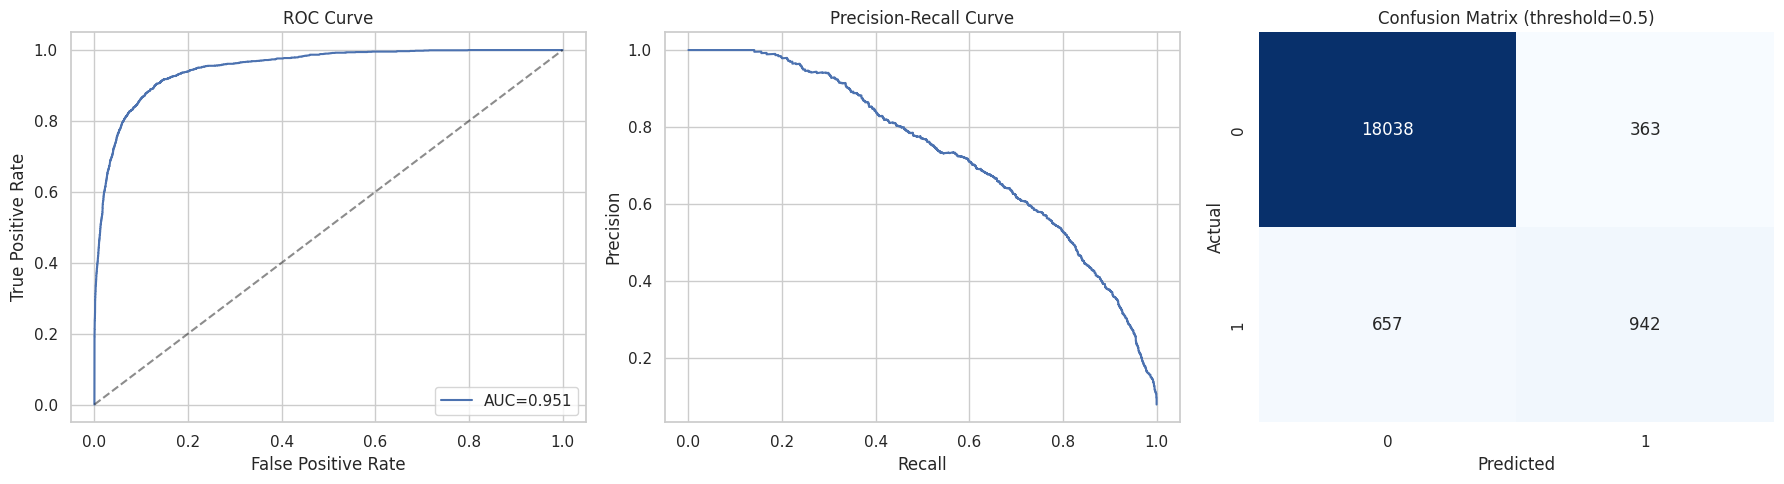

In [ ]:
pred_output = trainer.predict(eval_dataset)
logits = pred_output.predictions
y_true = pred_output.label_ids

y_prob = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
y_pred_05 = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_true, y_pred_05)
f1m = f1_score(y_true, y_pred_05, average="macro")
auc = roc_auc_score(y_true, y_prob)
cm = confusion_matrix(y_true, y_pred_05)

print(f"Accuracy:  {acc:.4f}")
print(f"F1 macro:  {f1m:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print("Confusion matrix:\n", cm)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr, tpr, label=f"AUC={auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")


precision, recall, _ = precision_recall_curve(y_true, y_prob)
axes[1].plot(recall, precision)
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[2])
axes[2].set_title("Confusion Matrix (threshold=0.5)")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [32]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []
for th in thresholds:
    pred = (y_prob >= th).astype(int)
    rows.append(
        {
            "threshold": th,
            "f1_macro": f1_score(y_true, pred, average="macro"),
            "accuracy": accuracy_score(y_true, pred),
        }
    )

th_df = pd.DataFrame(rows).sort_values("threshold")
display(th_df)

best_row = th_df.sort_values(["f1_macro", "accuracy"], ascending=False).iloc[0]
best_threshold = float(best_row["threshold"])
print(f"Selected threshold for later parts: {best_threshold:.1f}")
print("Reason: highest macro-F1 on held-out evaluation subset.")

,threshold,f1_macro,accuracy
0,0.3,0.813833,0.94230
1,0.4,0.814637,0.94685
2,0.5,0.810632,0.94900
3,0.6,0.794837,0.94815
4,0.7,0.778580,0.94735


Selected threshold for later parts: 0.4
Reason: highest macro-F1 on held-out evaluation subset.


## 11) Markdown Discussion Prompt (Fill After Running)

Use this section to answer the required question from the assignment:

- What does your chosen threshold imply about platform priorities?

Ans: A threshold of 0.4 implies a platform priority of being more proactive in catching harmful content, rather than being maximally conservative. It favors balanced performance across classes (toxic and non-toxic), which is important when toxic comments are the minority but high-impact class.

- Explain the trade-off between catching toxicity and avoiding false positives.

Ans: Lowering the threshold from 0.5 to 0.4 makes the model label toxicity more easily.Moreover benefit would be better recal but potentially more false positives.

- State why your selected threshold is appropriate for this baseline stage.

Ans: At baseline, the goal is to establish a strong and defensible operating point before fairness and calibration refinements in later parts. Threshold 0.4 is appropriate because it is empirically selected from held-out results and optimizes the main selection metric (macro-F1), while accuracy remains high and close to the best observed values.
